In [36]:
# Base.invokelatest(include, localpath("src/Deborah.jl"))
# import .Deborah
using Revise
import Deborah; flush(stdout); flush(stderr)

In [37]:
const PROJECT_ROOT = joinpath(homedir(), "work", "Deborah.jl")
function localpath(relpath::AbstractString)
    return joinpath(PROJECT_ROOT, relpath)
end

work = "nf4_clover_wilson_finiteT"

ns = 12
nt = 4
b = "1.60"

basepath = localpath(work)
prefix   = "L$(ns)T$(nt)b$(b)"

ensembles = filter(entry -> isdir(joinpath(basepath, entry)),
                   readdir(basepath; join=true)) .|> basename |>
            x -> filter(e -> startswith(e, prefix), x)

raw_paths = [localpath(joinpath(work, ens)) for ens in ensembles]

jobid = nothing

In [38]:
import Statistics

observable="plaq.dat"
# observable="rect.dat"
# observable="pbp.dat"

X_dfs = [Deborah.Sarah.DataLoader.load_data_file(raw_path, observable, jobid) for raw_path in raw_paths]

N_cnfs = [size(X_df, 1) for X_df in X_dfs]

N_src = 1
read_column_X = 1

X_infos = [Deborah.Sarah.XYInfoGenerator.gen_X_info(X_df, N_cnf, N_src, read_column_X) for (X_df, N_cnf) in zip(X_dfs, N_cnfs)]

# X_info = Deborah.Sarah.XYInfoGenerator.gen_X_info(X_df, N_cnf, N_src, read_column_X)


X_info_ORGs = [
    [Statistics.mean(X_info[read_column_X, iconf, :]) for iconf in 1:N_cnf]
    for (X_info, N_cnf) in zip(X_infos, N_cnfs)
]

conf_idx_vecs = [1:N_cnf for N_cnf in N_cnfs]
conf_idxs = [collect(conf_idx_vec) for conf_idx_vec in conf_idx_vecs]

Deborah.Rebekah.PyPlotLaTeX.set_pyplot_latex_style()

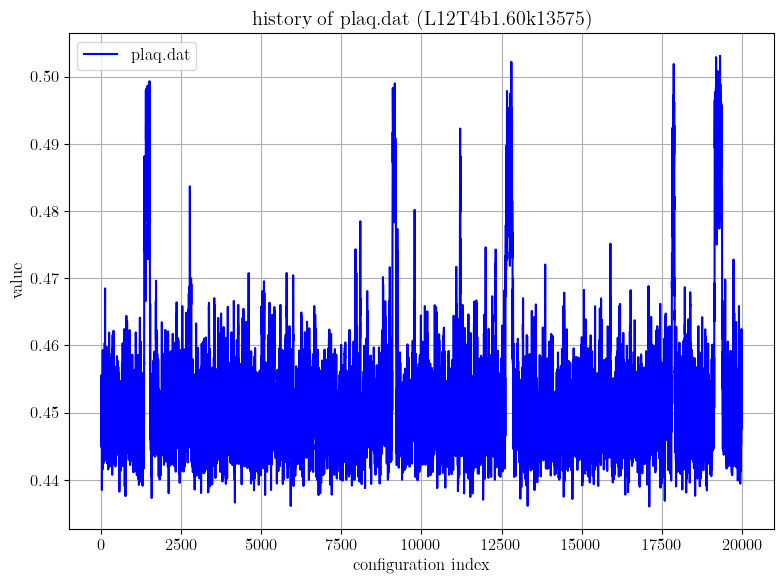

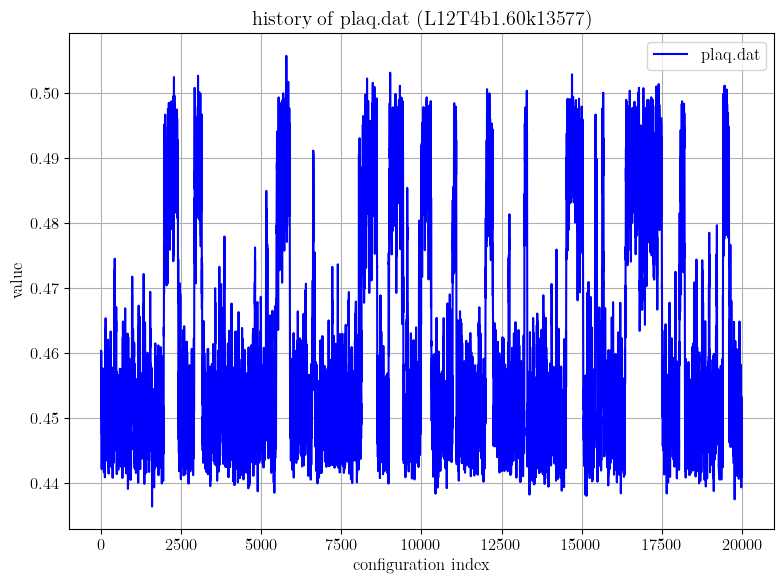

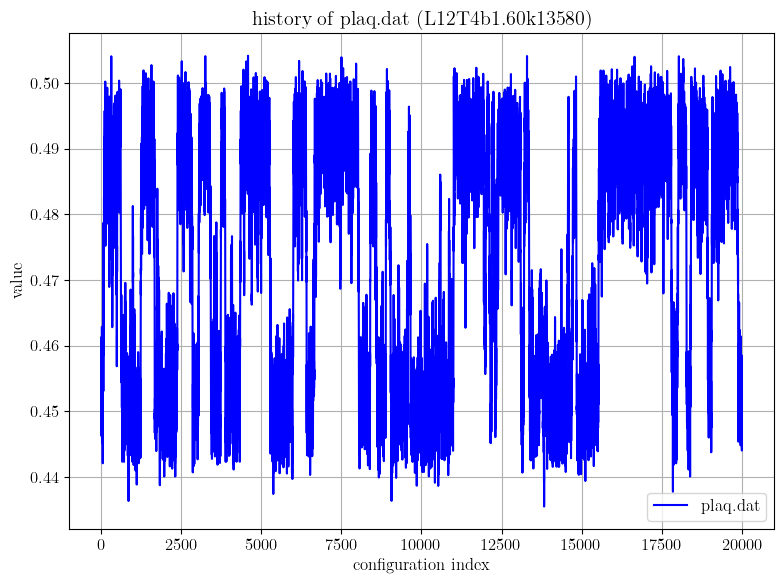

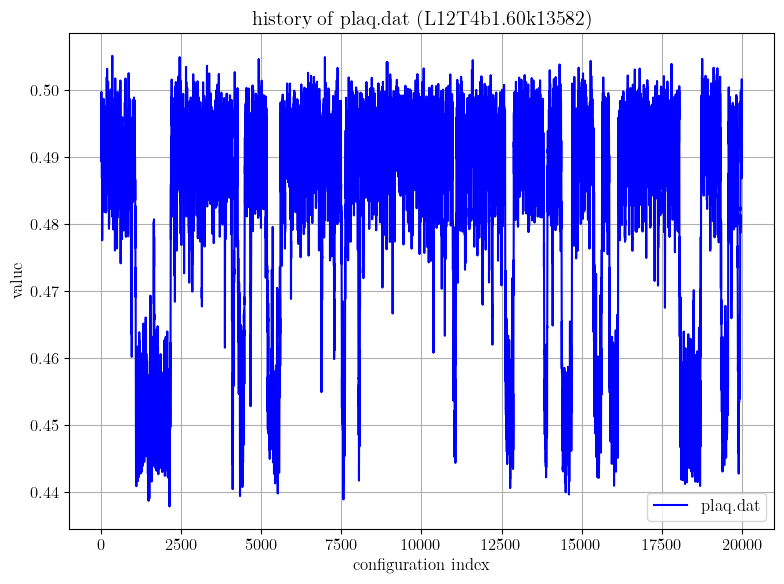

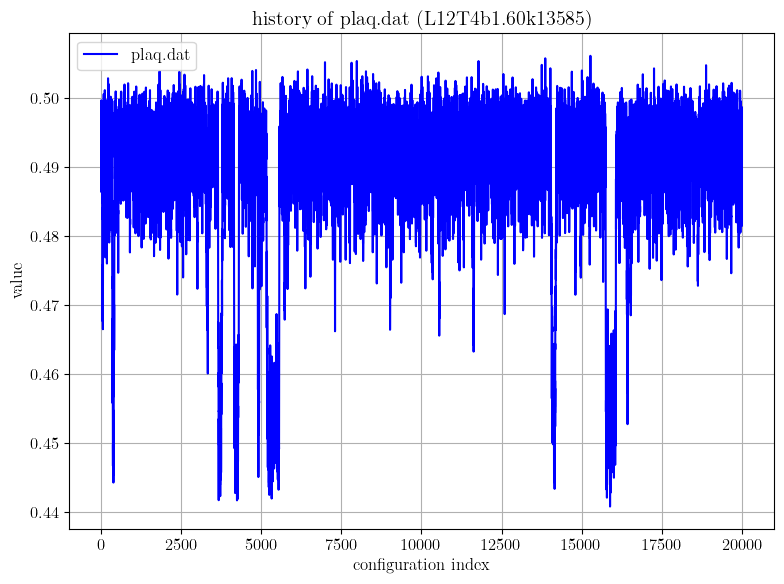

In [39]:
for (ens, conf_idx, X_info_ORG) in zip(ensembles, conf_idxs, X_info_ORGs)
    Deborah.Rahab.ObservableHistory.observable_history(ens, conf_idx, X_info_ORG, observable)
end

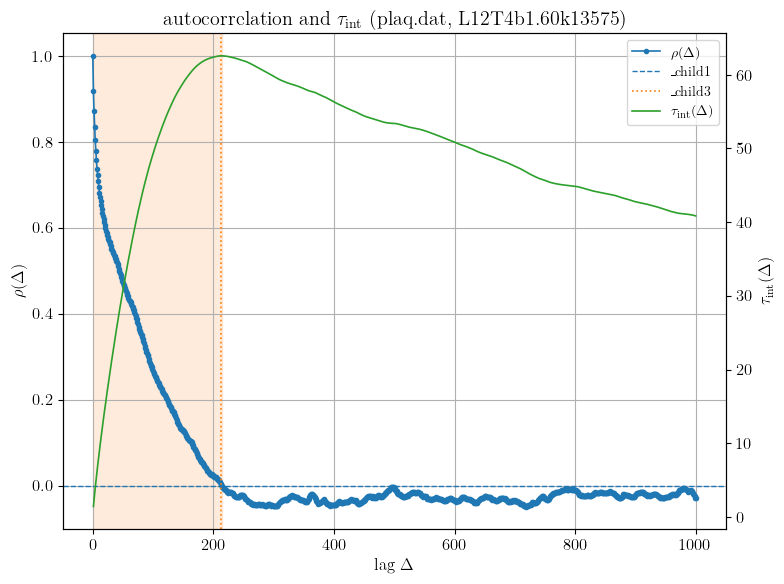

[autocorr] ensemble=L12T4b1.60k13575, obs=plaq.dat: tau_int≈62.569, two_tau≈125.139, Δ_cut=213
[autocorr] ensemble=L12T4b1.60k13577, obs=plaq.dat: tau_int≈135.077, two_tau≈270.155, Δ_cut=354
[autocorr] ensemble=L12T4b1.60k13580, obs=plaq.dat: tau_int≈238.988, two_tau≈477.975, Δ_cut=1000
[autocorr] ensemble=L12T4b1.60k13582, obs=plaq.dat: tau_int≈162.913, two_tau≈325.826, Δ_cut=601
[autocorr] ensemble=L12T4b1.60k13585, obs=plaq.dat: tau_int≈107.132, two_tau≈214.263, Δ_cut=655


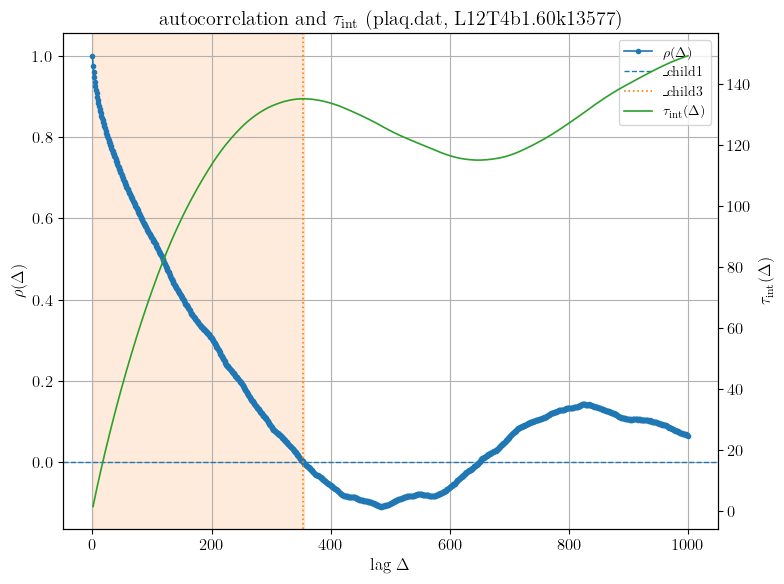

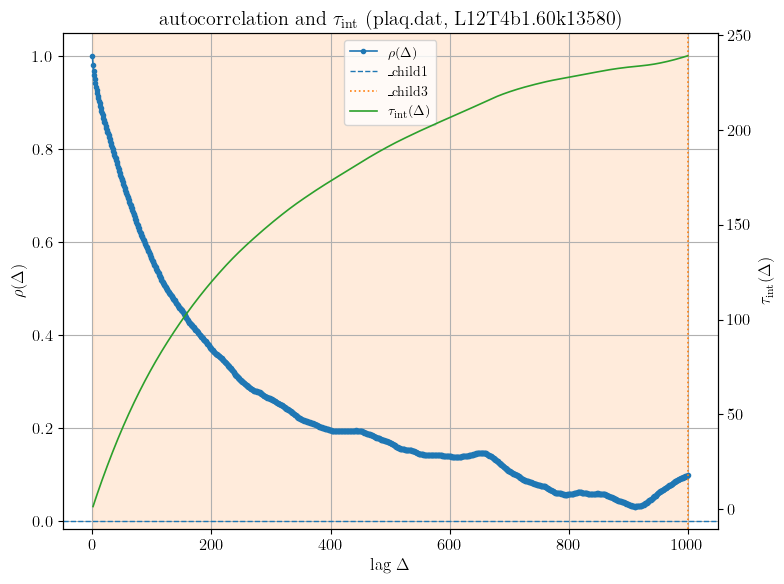

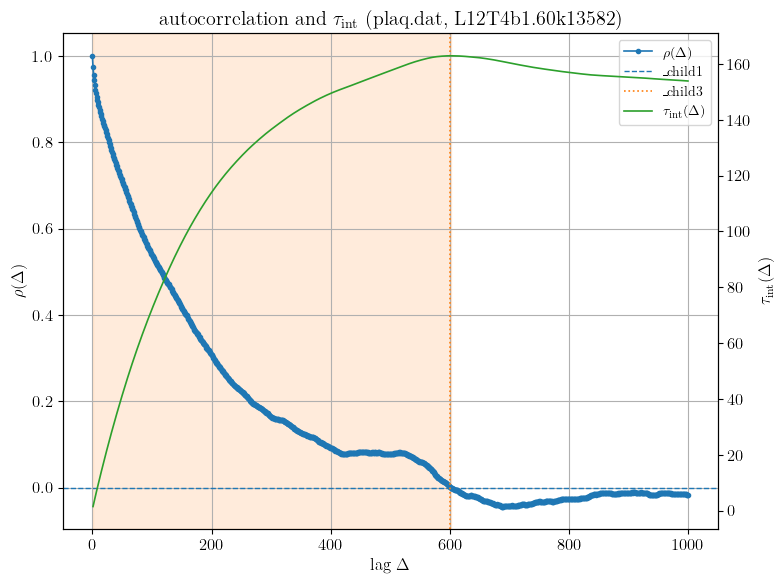

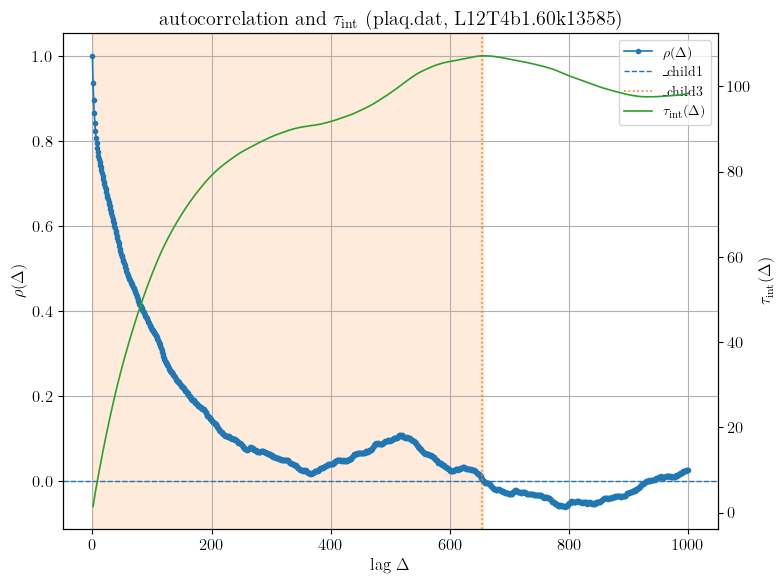

In [40]:
for (ens, X_info_ORG) in zip(ensembles, X_info_ORGs)
    Deborah.Rahab.ObservableHistory.plot_autocorr_tauint(ens, X_info_ORG, observable;
        maxlag=1000, window=:first_nonpositive)
end

[2025-10-19 10:20:35.192] Seed for PRNG = 850528
[2025-10-19 10:20:35.193] PRNG for StatsBase = Random.Xoshiro(0xe4b6359c1596dead, 0x9f9e27ff1b8ba5cc, 0xf40dad836ca8b9ee, 0xf537c0ce691e310a, 0x3c5b56cf6758c8fd)
Divisors of 1000: [1, 2, 4, 5, 8, 10, 20, 25, 40, 50, 100, 125, 200, 250, 500, 1000]
[2025-10-19 10:20:36.213] Seed for PRNG = 850528
[2025-10-19 10:20:36.213] PRNG for StatsBase = Random.Xoshiro(0xe4b6359c1596dead, 0x9f9e27ff1b8ba5cc, 0xf40dad836ca8b9ee, 0xf537c0ce691e310a, 0x3c5b56cf6758c8fd)
Divisors of 1000: [1, 2, 4, 5, 8, 10, 20, 25, 40, 50, 100, 125, 200, 250, 500, 1000]
[2025-10-19 10:20:37.119] Seed for PRNG = 850528
[2025-10-19 10:20:37.120] PRNG for StatsBase = Random.Xoshiro(0xe4b6359c1596dead, 0x9f9e27ff1b8ba5cc, 0xf40dad836ca8b9ee, 0xf537c0ce691e310a, 0x3c5b56cf6758c8fd)
Divisors of 1000: [1, 2, 4, 5, 8, 10, 20, 25, 40, 50, 100, 125, 200, 250, 500, 1000]
[2025-10-19 10:20:38.076] Seed for PRNG = 850528
[2025-10-19 10:20:38.076] PRNG for StatsBase = Random.Xoshiro(0

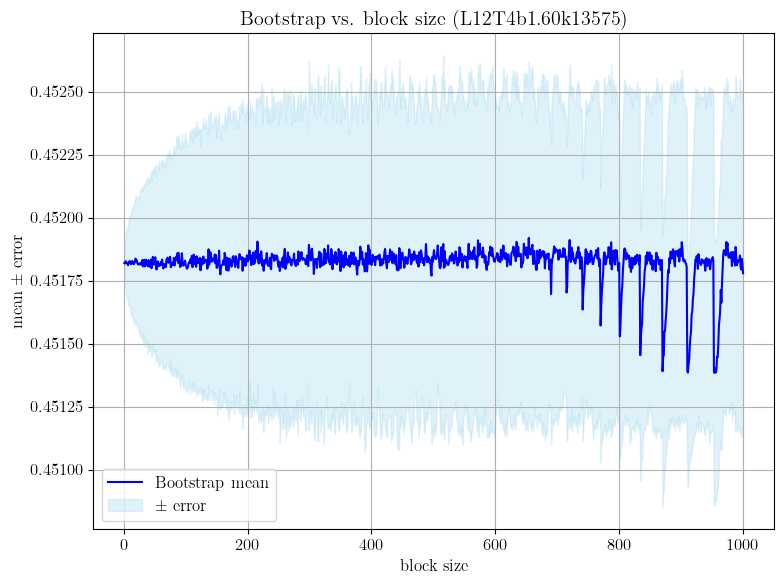

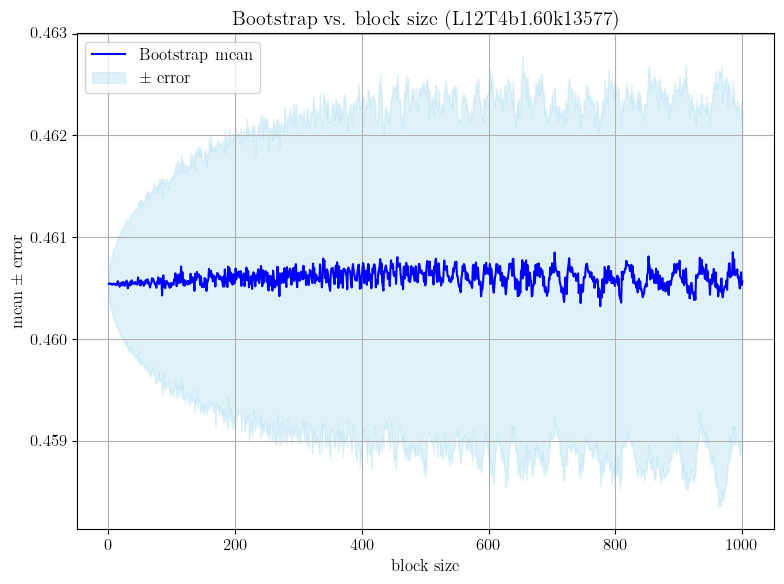

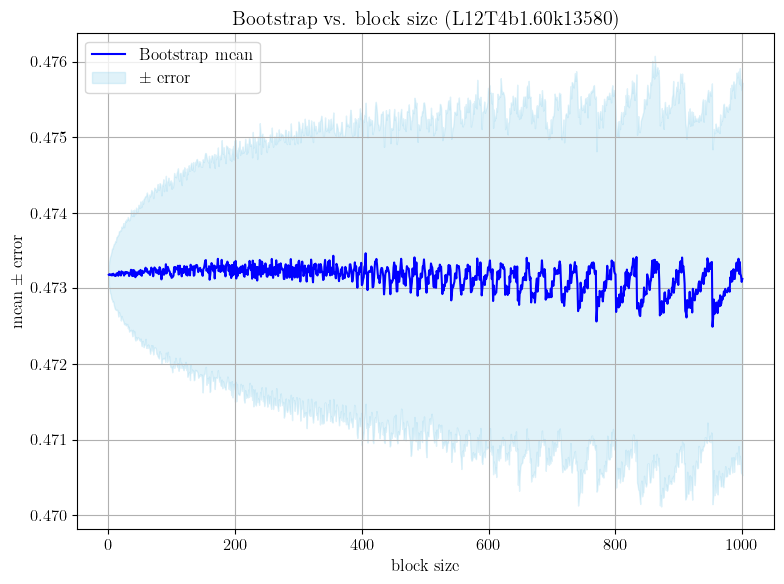

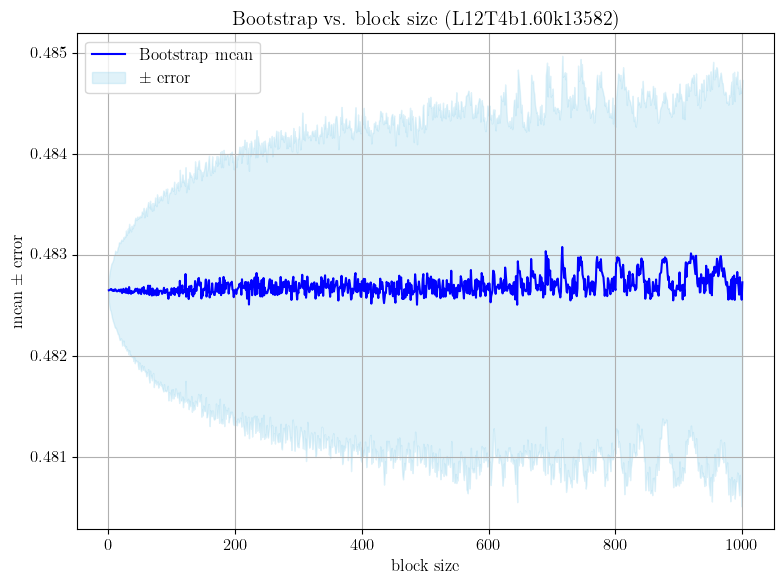

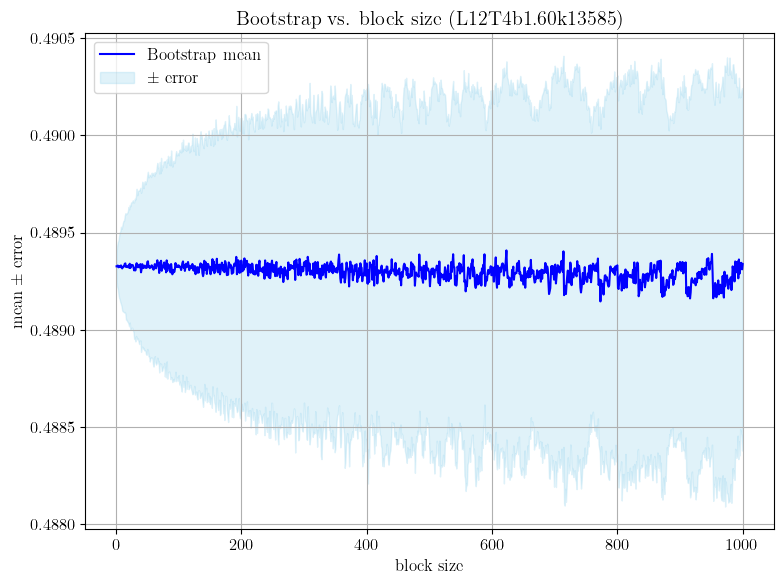

In [41]:
N_bs = 1000
tot_bin = 1000
ranseed = 850528

bin_sizes_vec = [collect(1:min(tot_bin, N_cnf)) for N_cnf in N_cnfs]

means_vec = Vector{Vector{Float64}}(undef, length(ensembles))
errs_vec  = Vector{Vector{Float64}}(undef, length(ensembles))

for (i, (ens, X_info_ORG, bin_sizes, N_cnf)) in enumerate(zip(ensembles, X_info_ORGs, bin_sizes_vec, N_cnfs))
    rng = Deborah.Sarah.SeedManager.setup_rng(ranseed, jobid)
    means_vec[i], errs_vec[i] = Deborah.Rahab.BlockBinScan.bootstrap_block_scan(
        ens,
        X_info_ORG,
        bin_sizes,
        N_bs,
        tot_bin,
        rng;
        method="nonoverlapping"
    )
end

In [42]:
win = 50  # window of block size; e.g., 10 means [1..10], [11..20], ... 

50

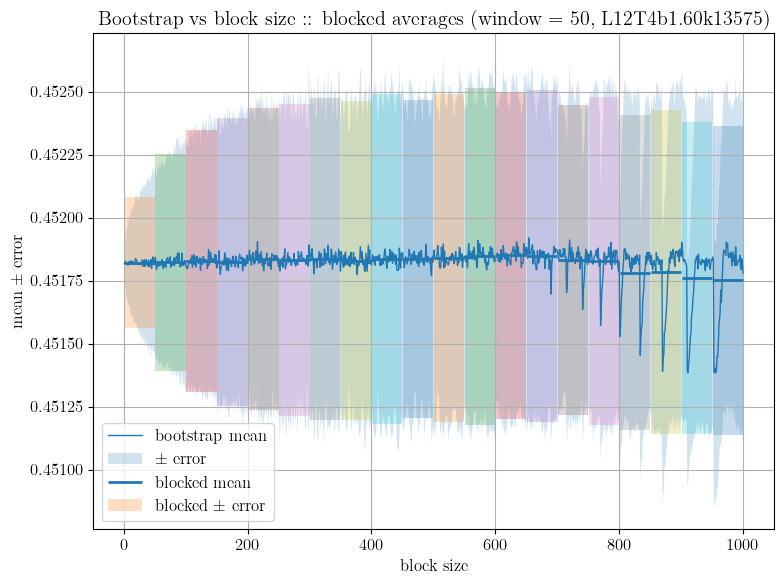

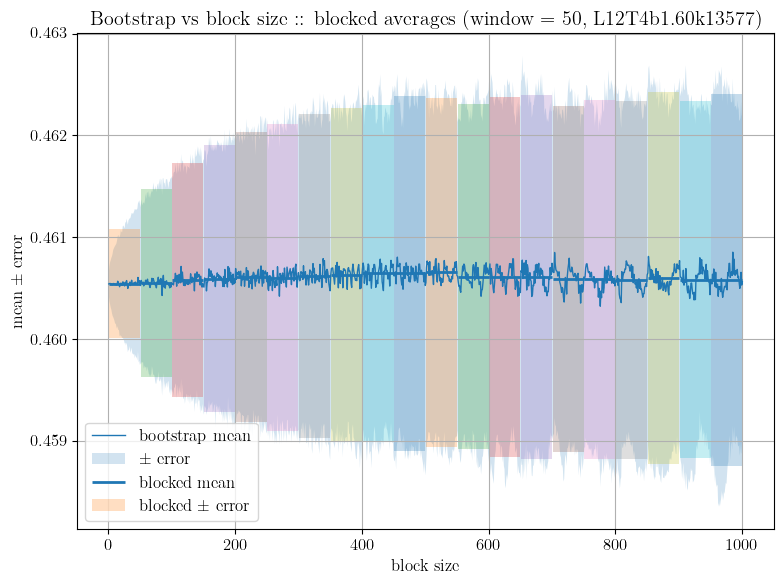

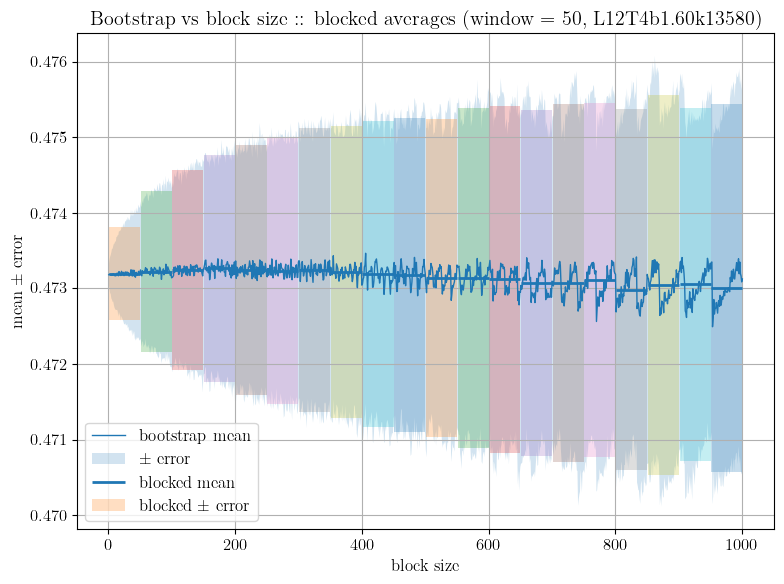

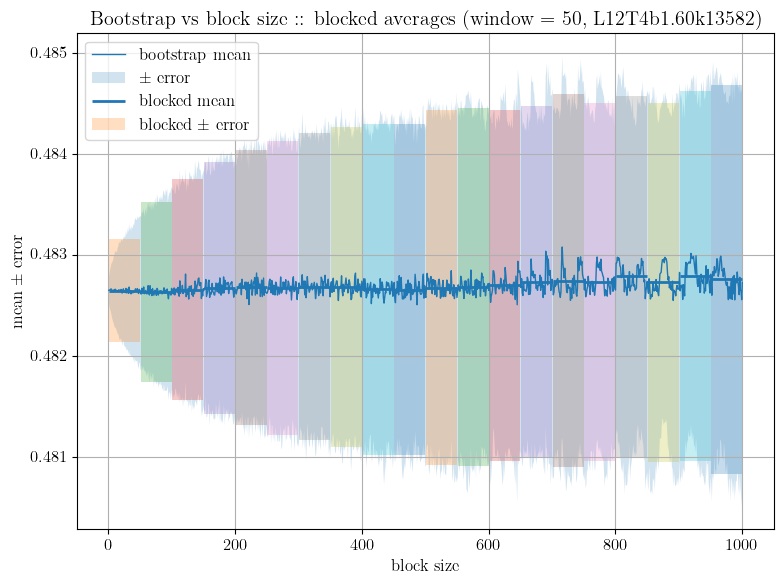

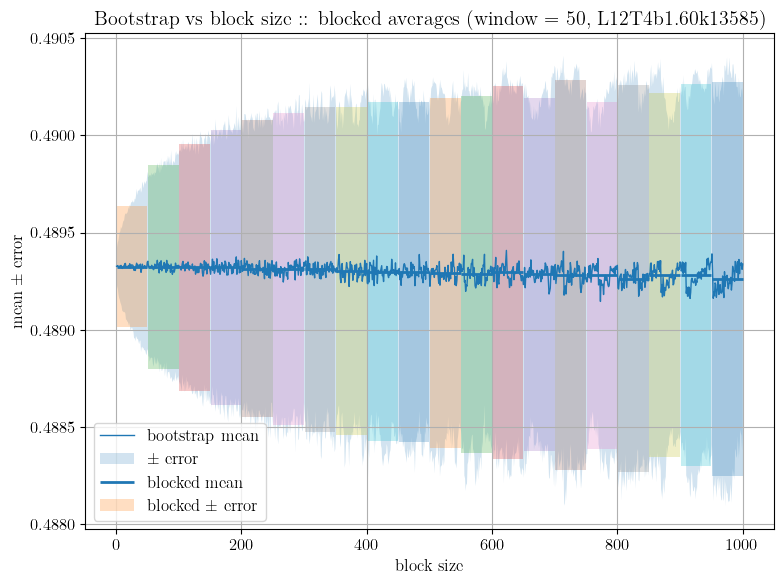

In [43]:
for (i, (ens, bin_sizes, means, errs)) in enumerate(zip(ensembles, bin_sizes_vec, means_vec, errs_vec))
    Deborah.Rahab.BlockBinScan.bootstrap_block_scan_blocked_average(
        ens,
        bin_sizes,
        means,
        errs,
        win;
        include_tail=false
    )
end

In [44]:
# for (i, (ens, bin_sizes, means, errs)) in enumerate(zip(ensembles, bin_sizes_vec, means_vec, errs_vec))
#     Deborah.Rahab.BlockBinScan.nsr_block_scan(
#         ens,
#         bin_sizes,
#         means,
#         errs;
#         logscale=true
#     )
# end

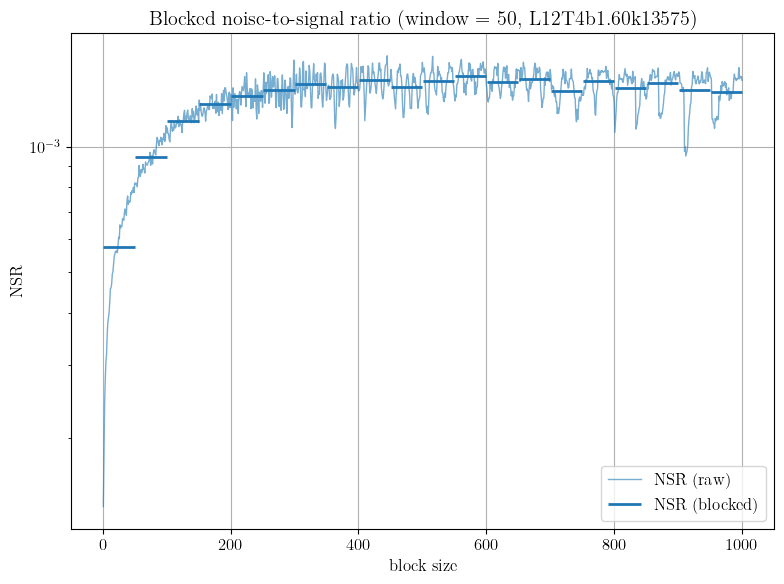

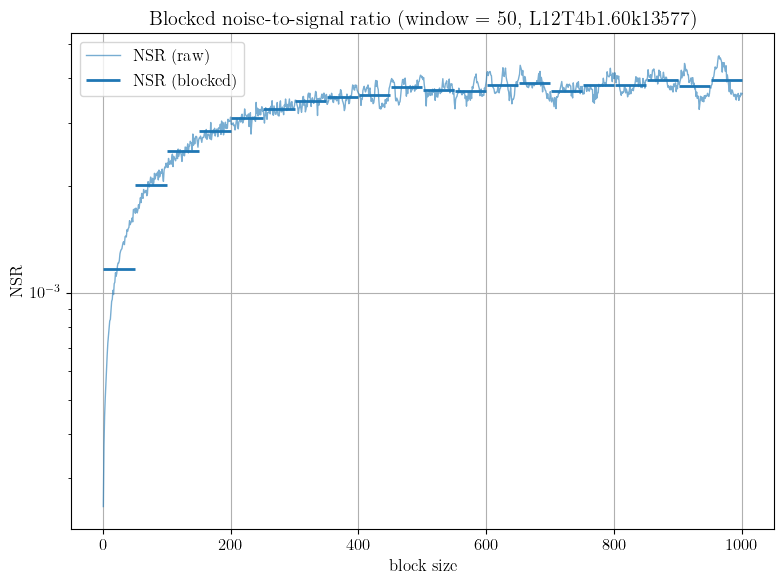

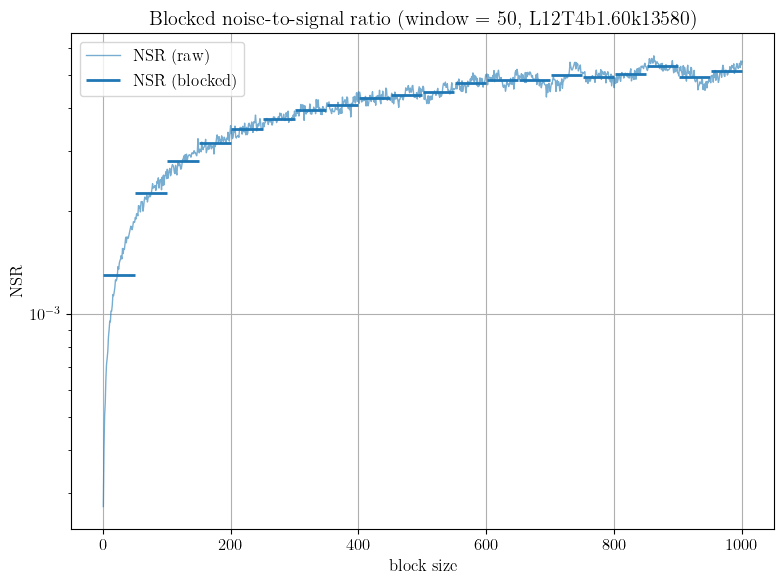

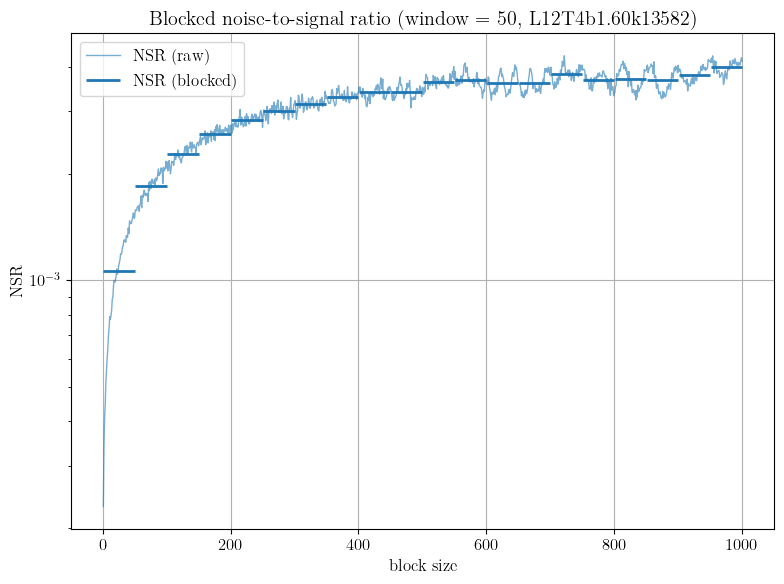

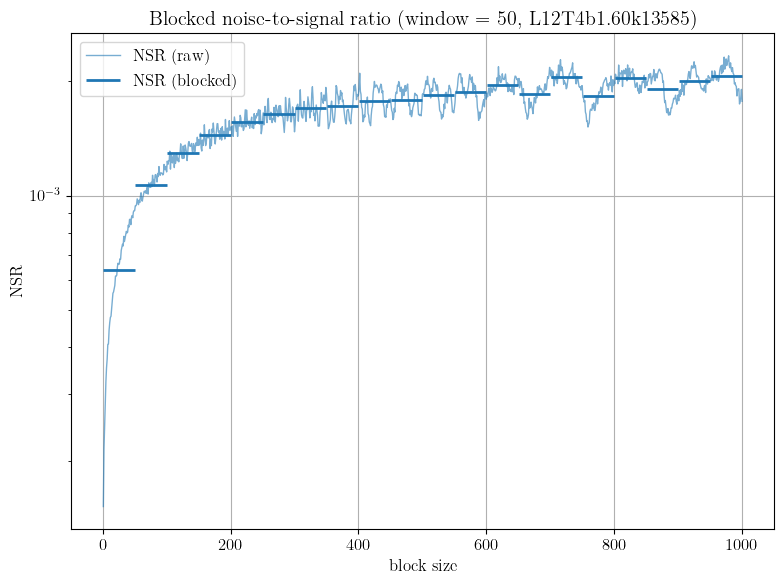

In [45]:
for (i, (ens, bin_sizes, means, errs)) in enumerate(zip(ensembles, bin_sizes_vec, means_vec, errs_vec))
    Deborah.Rahab.BlockBinScan.nsr_block_scan_blocked_average(
        ens,
        bin_sizes,
        means,
        errs,
        win;
        include_tail=false,
        logscale=true
    )
end

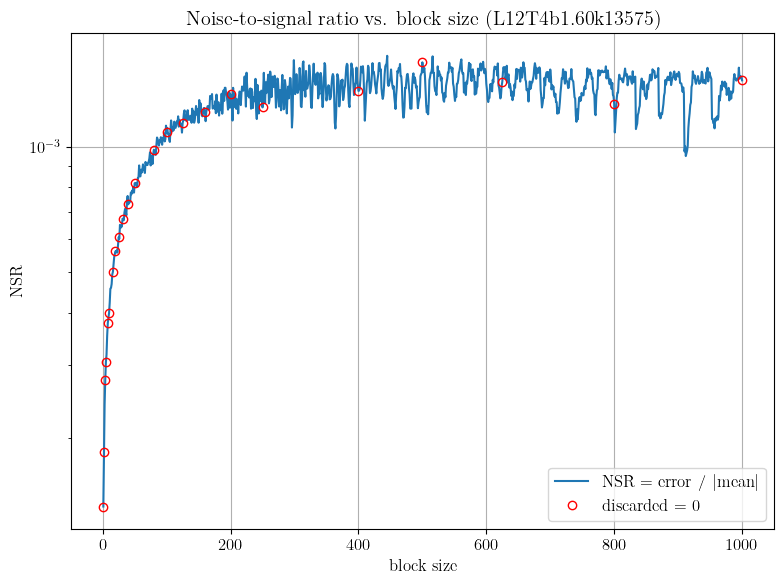

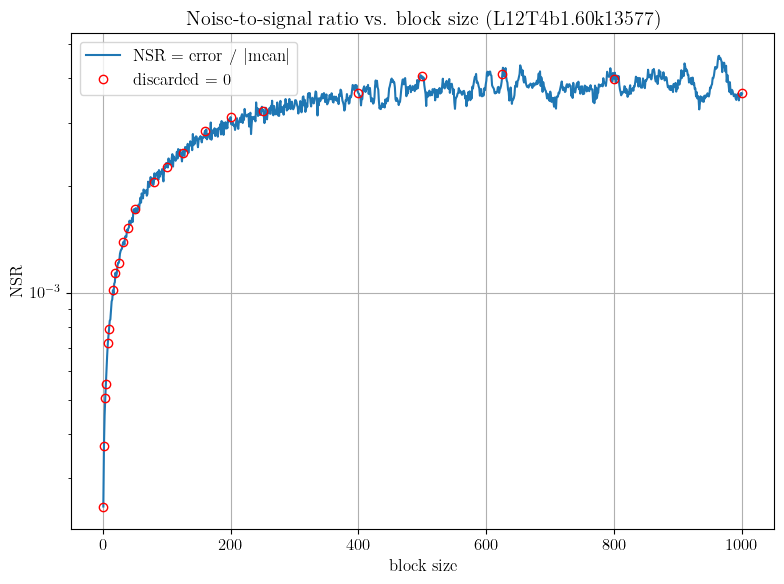

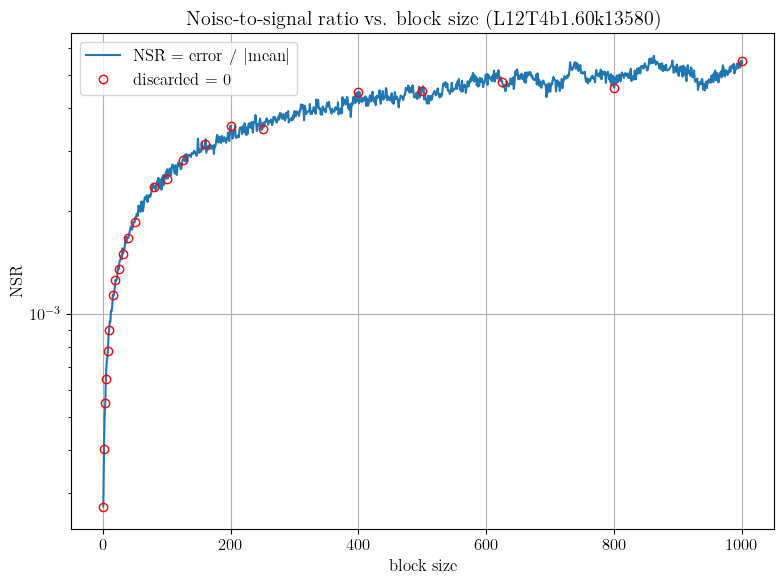

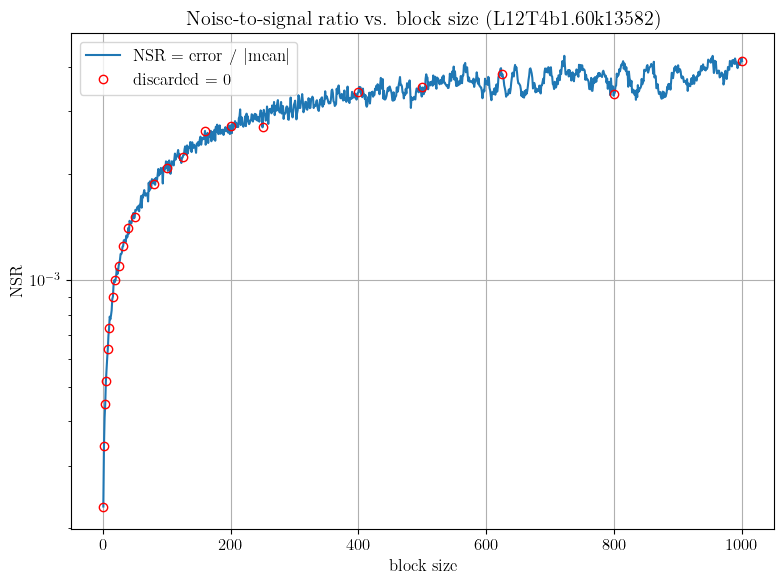

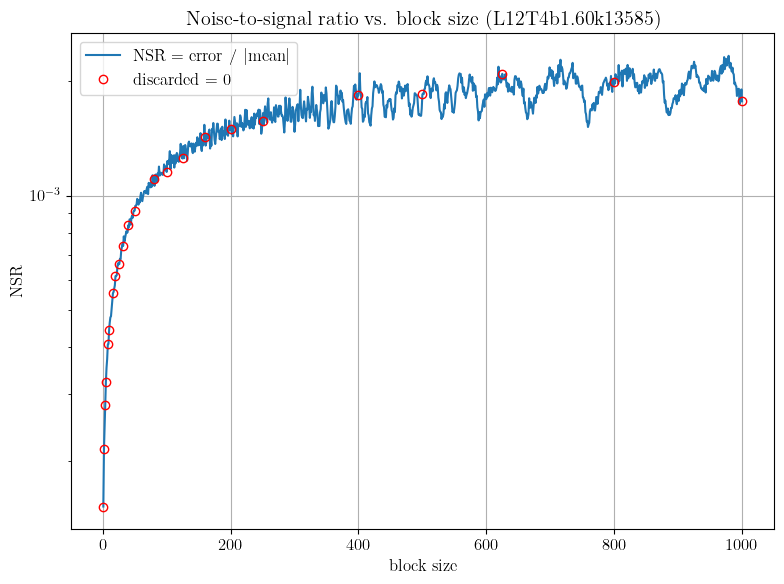

In [46]:
for (i, (ens, X_info_ORG, means, errs)) in enumerate(zip(ensembles, X_info_ORGs, means_vec, errs_vec))
    Deborah.Rahab.BlockBinScan.nsr_block_scan_with_discarded_zero(
        ens,
        X_info_ORG,
        tot_bin,
        means,
        errs;
        logscale=true
    )
end

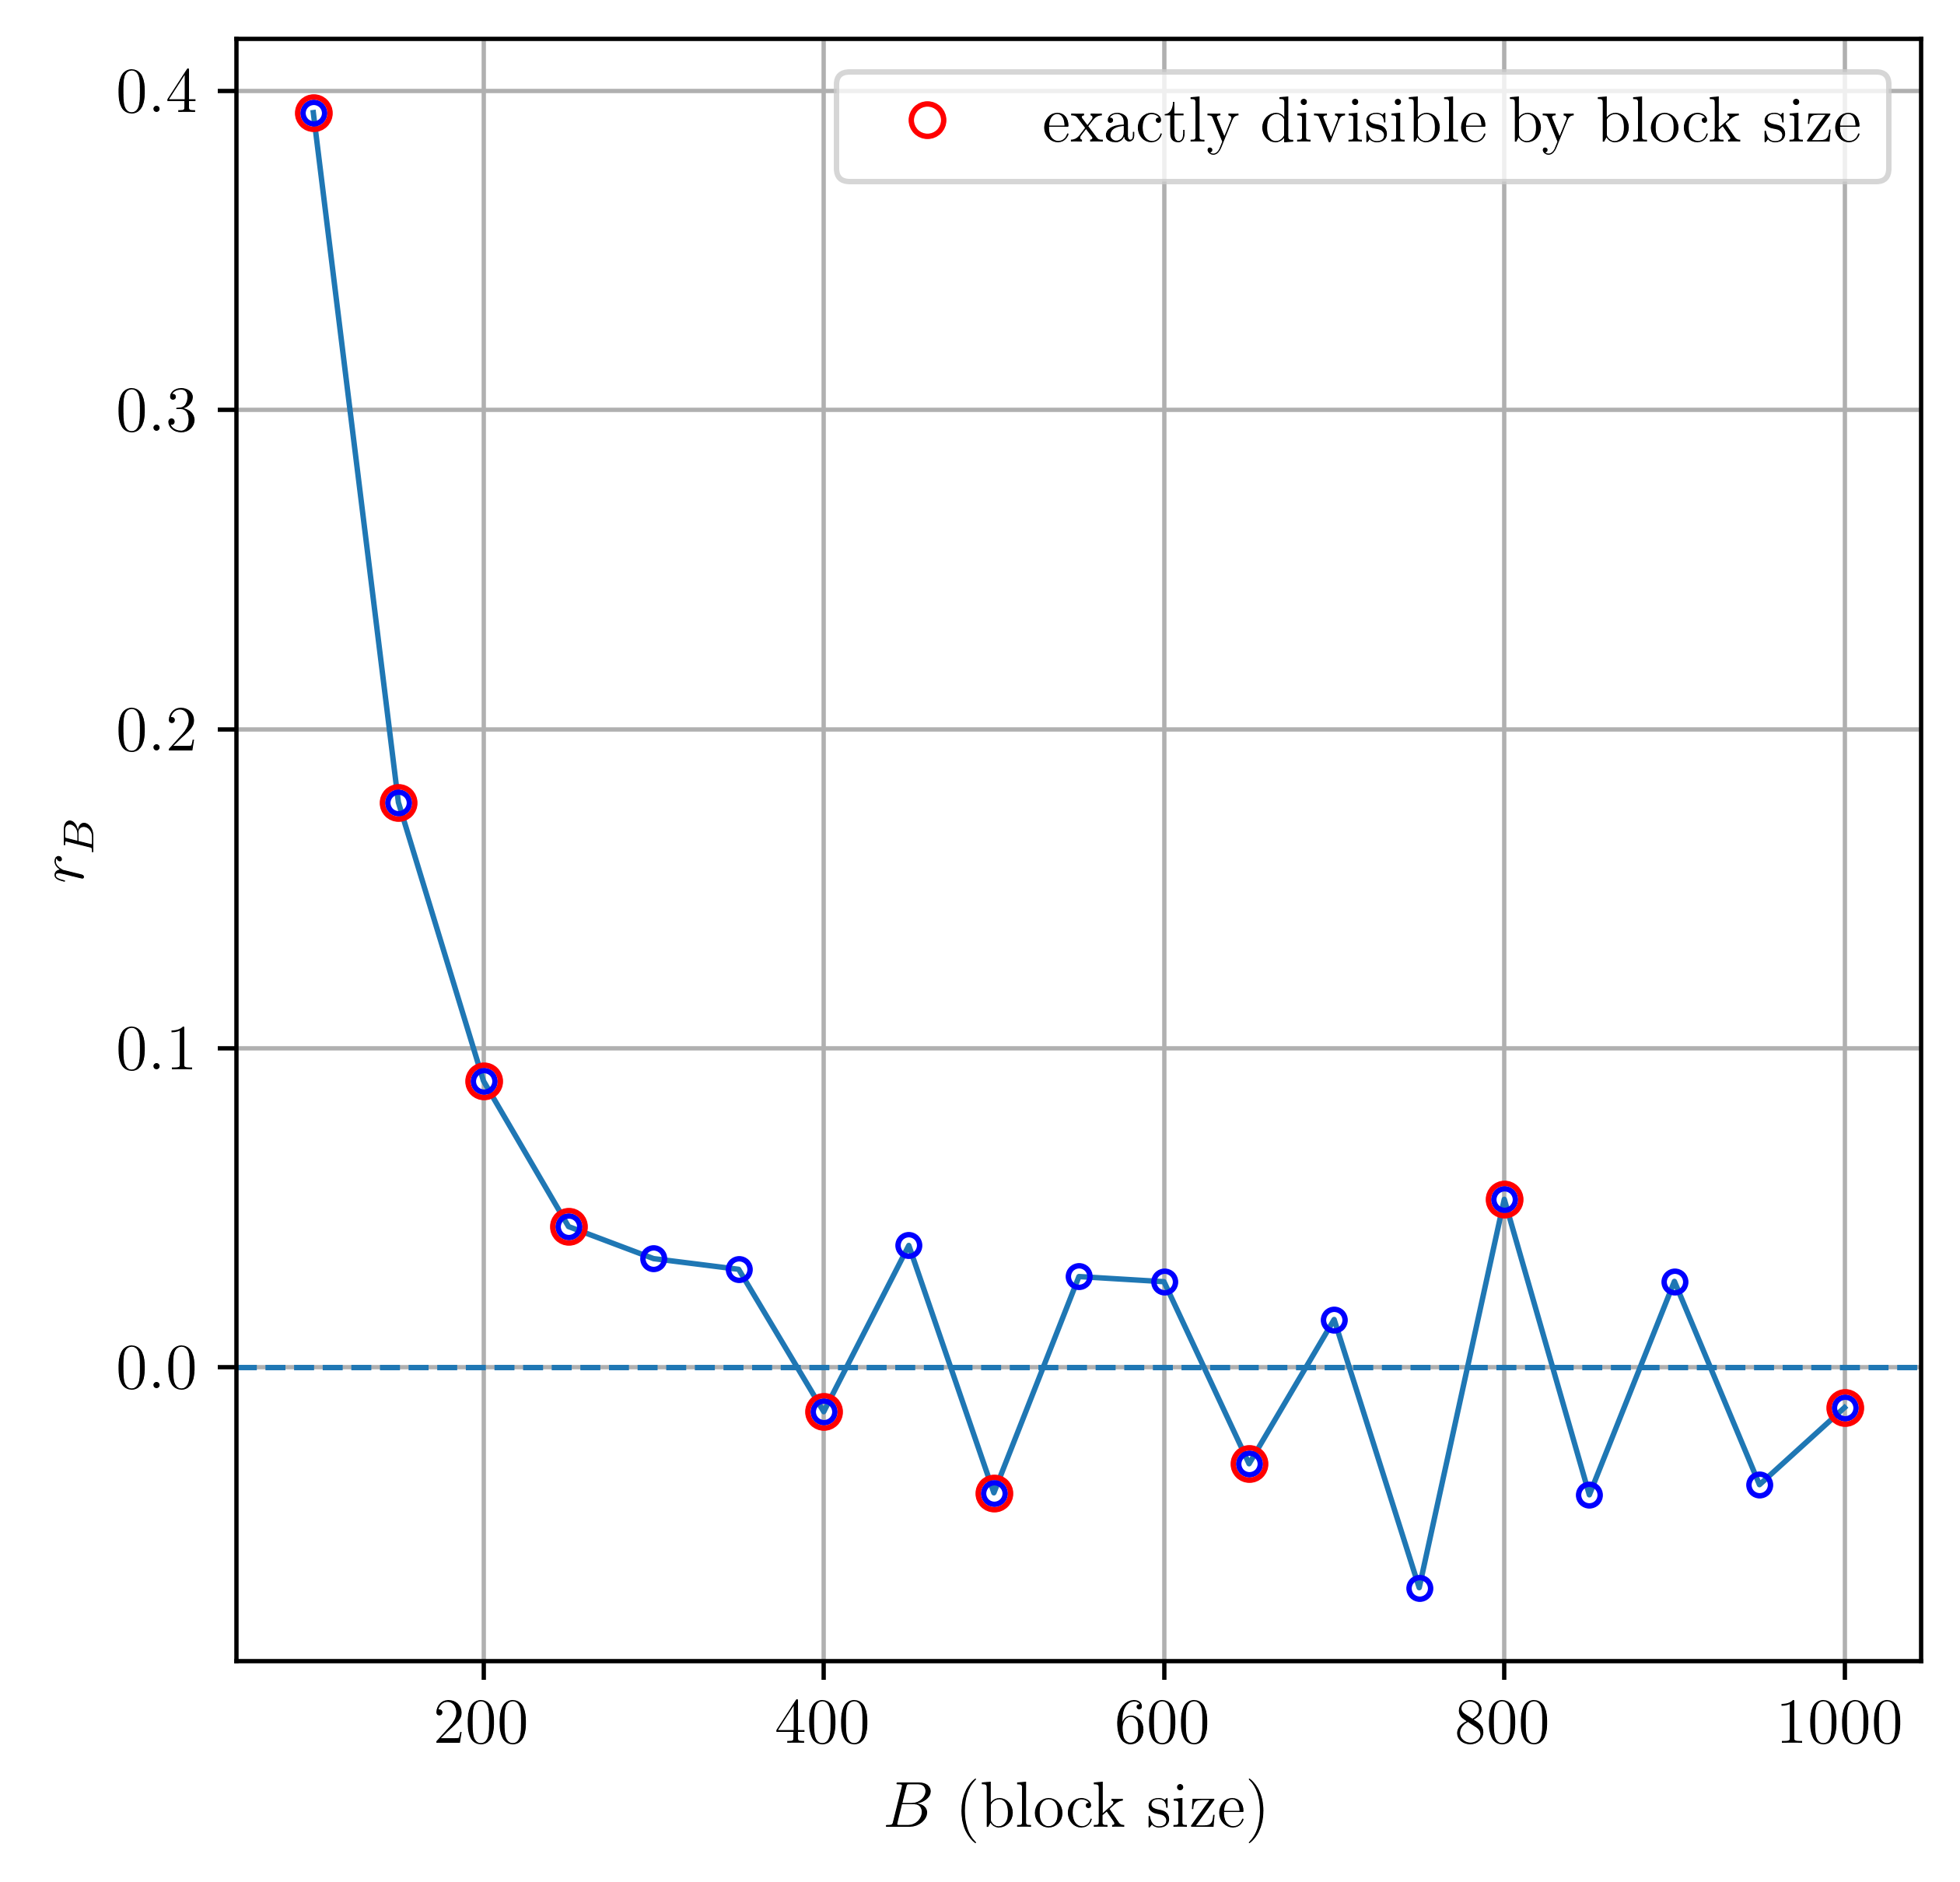

PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `./block_size_resid_L12T4b1.60k13575_win_size_50-crop.pdf'.
block sizes with discarded == 0: [1, 2, 4, 5, 8, 10, 16, 20, 25, 32, 40, 50, 80, 100, 125, 160, 200, 250, 400, 500, 625, 800, 1000]
window indices (k) that contain any discarded == 0: [2, 3, 4, 5, 8, 10, 13, 16, 20]
x(right-edge) for those windows: [100, 150, 200, 250, 400, 500, 650, 800, 1000]
PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `./block_size_resid_L12T4b1.60k13577_win_size_50-crop.pdf'.
block sizes with discarded == 0: [1, 2, 4, 5, 8, 10, 16, 20, 25, 32, 40, 50, 80, 100, 125, 160, 200, 250, 400, 500, 625, 800, 1000]
window indices (k) that contain any discarded == 0: [2, 3, 4, 5, 8, 10, 13, 16, 20]
x(right-edge) for those windows: [100, 150, 200, 250, 400, 500, 650, 800, 1000]
PDFCROP 1.42, 2023/04/15 - Copyright (c)

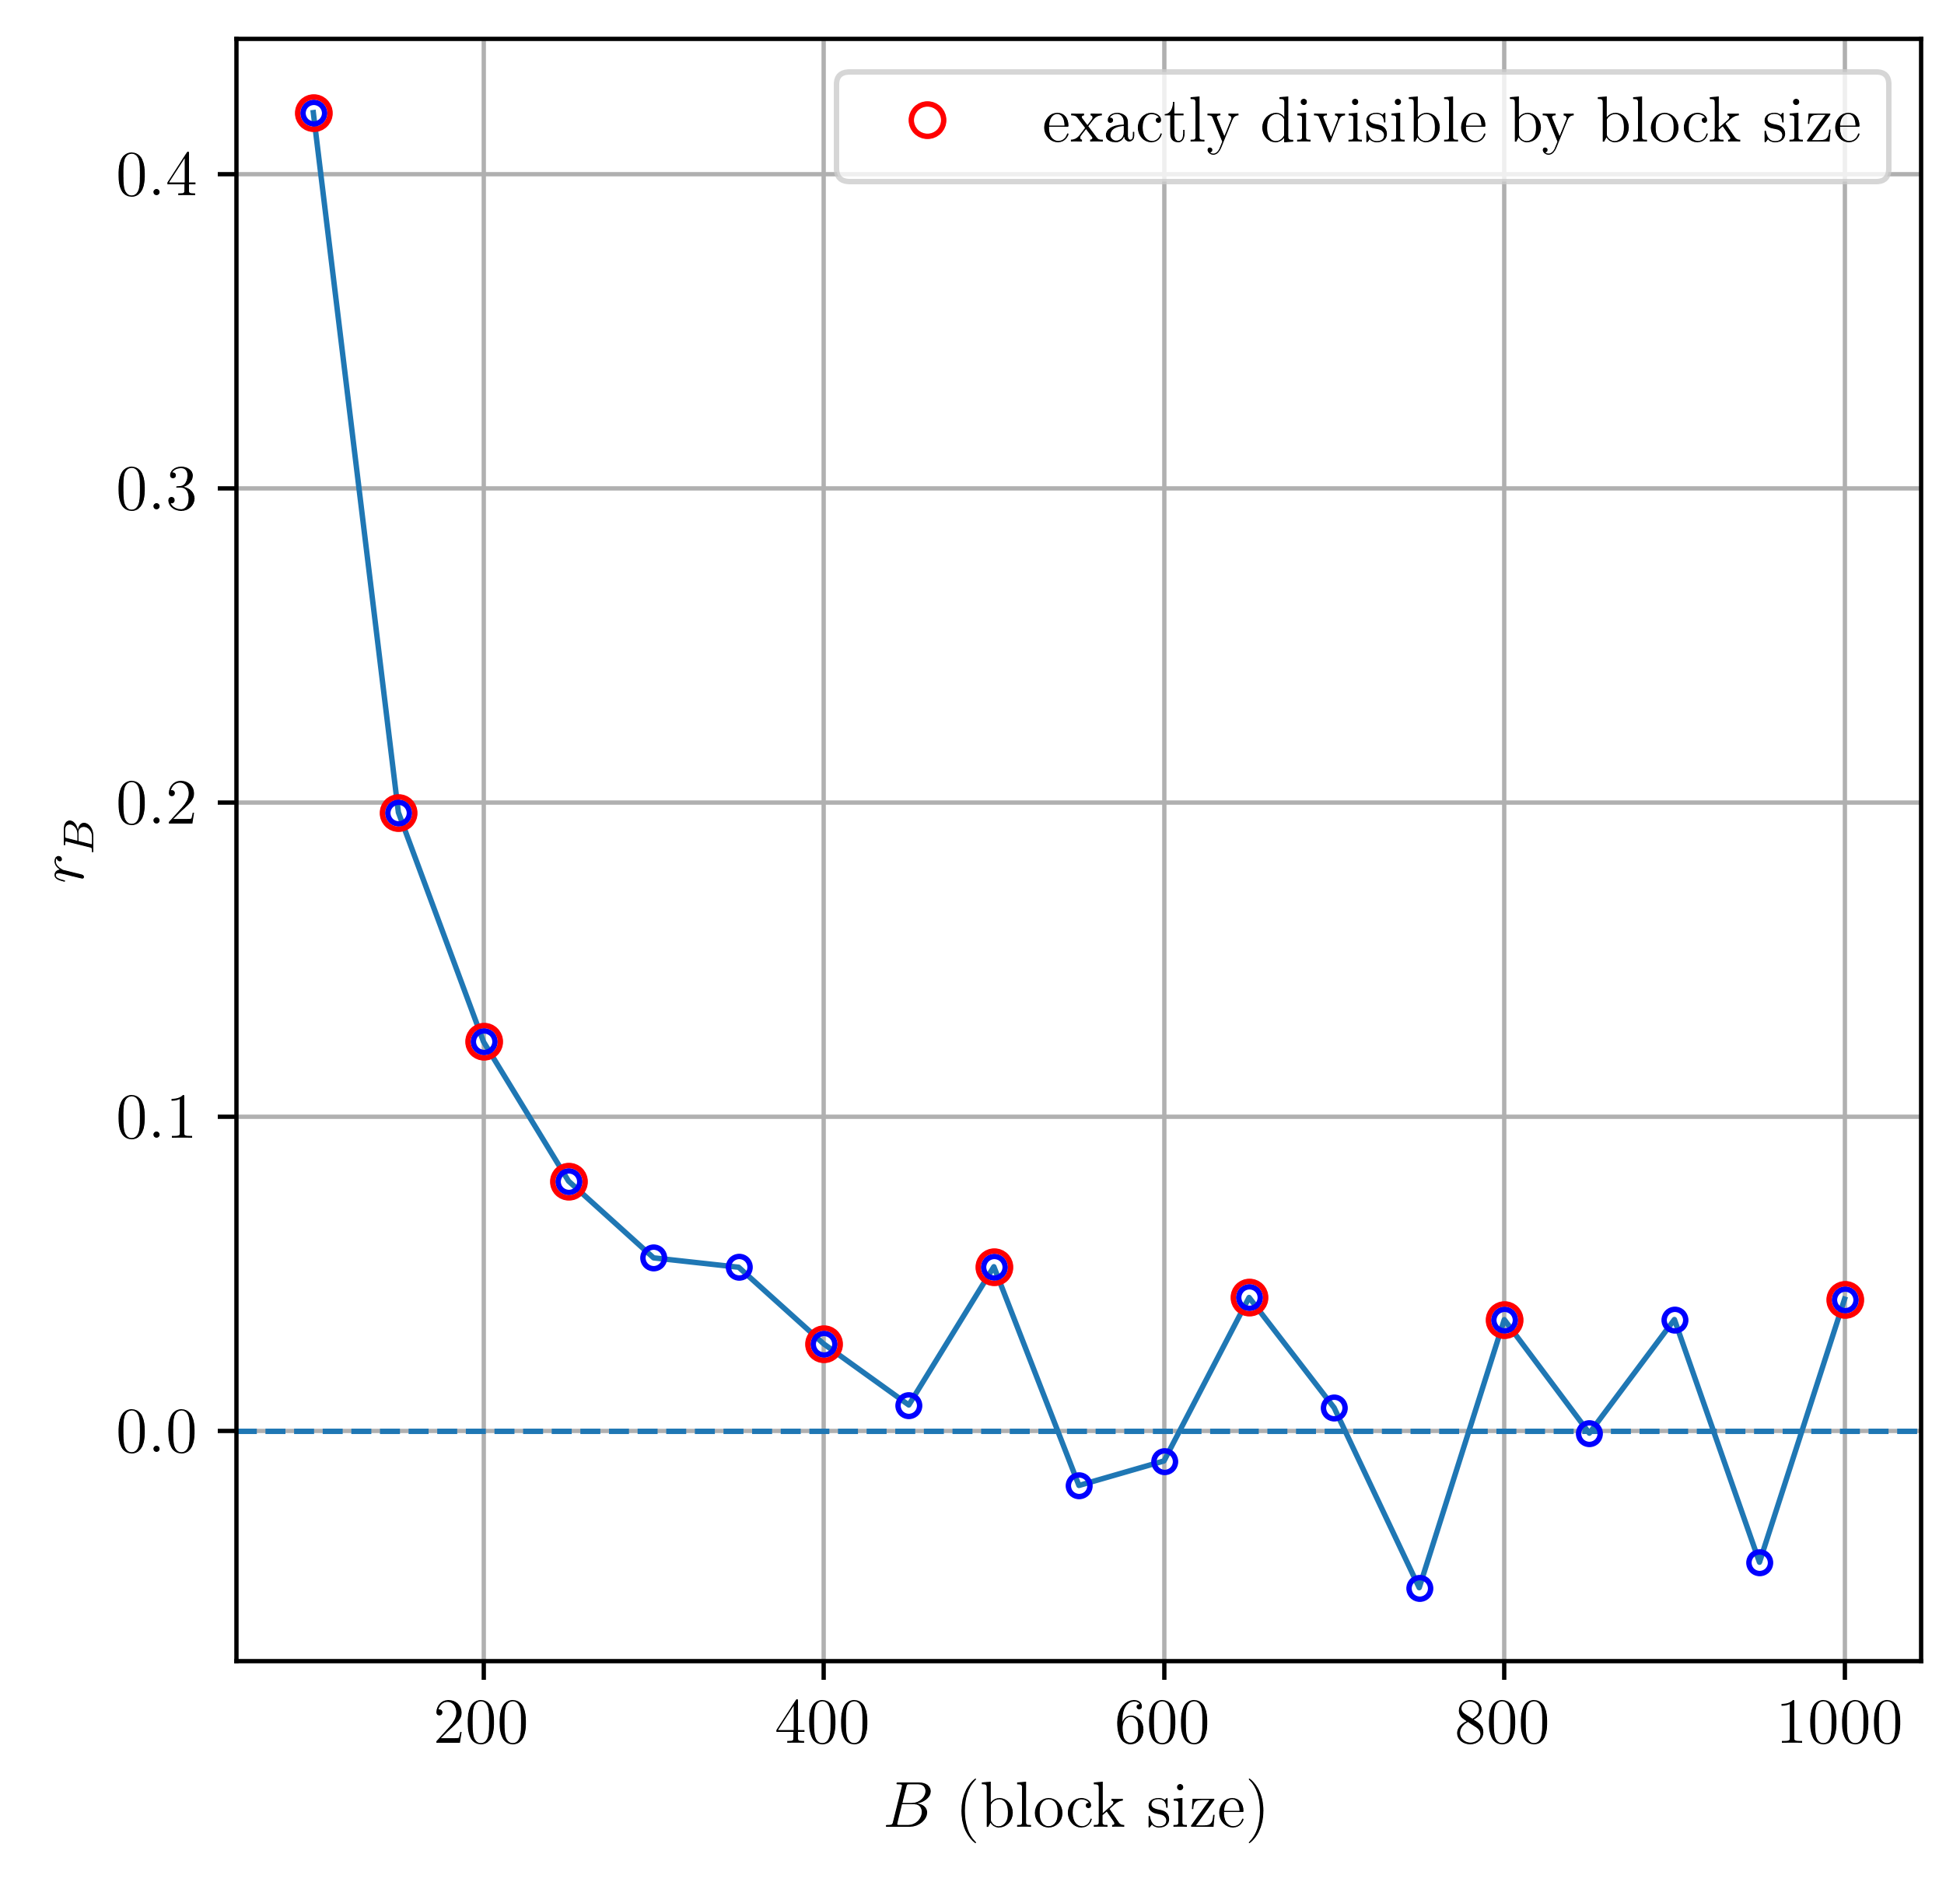

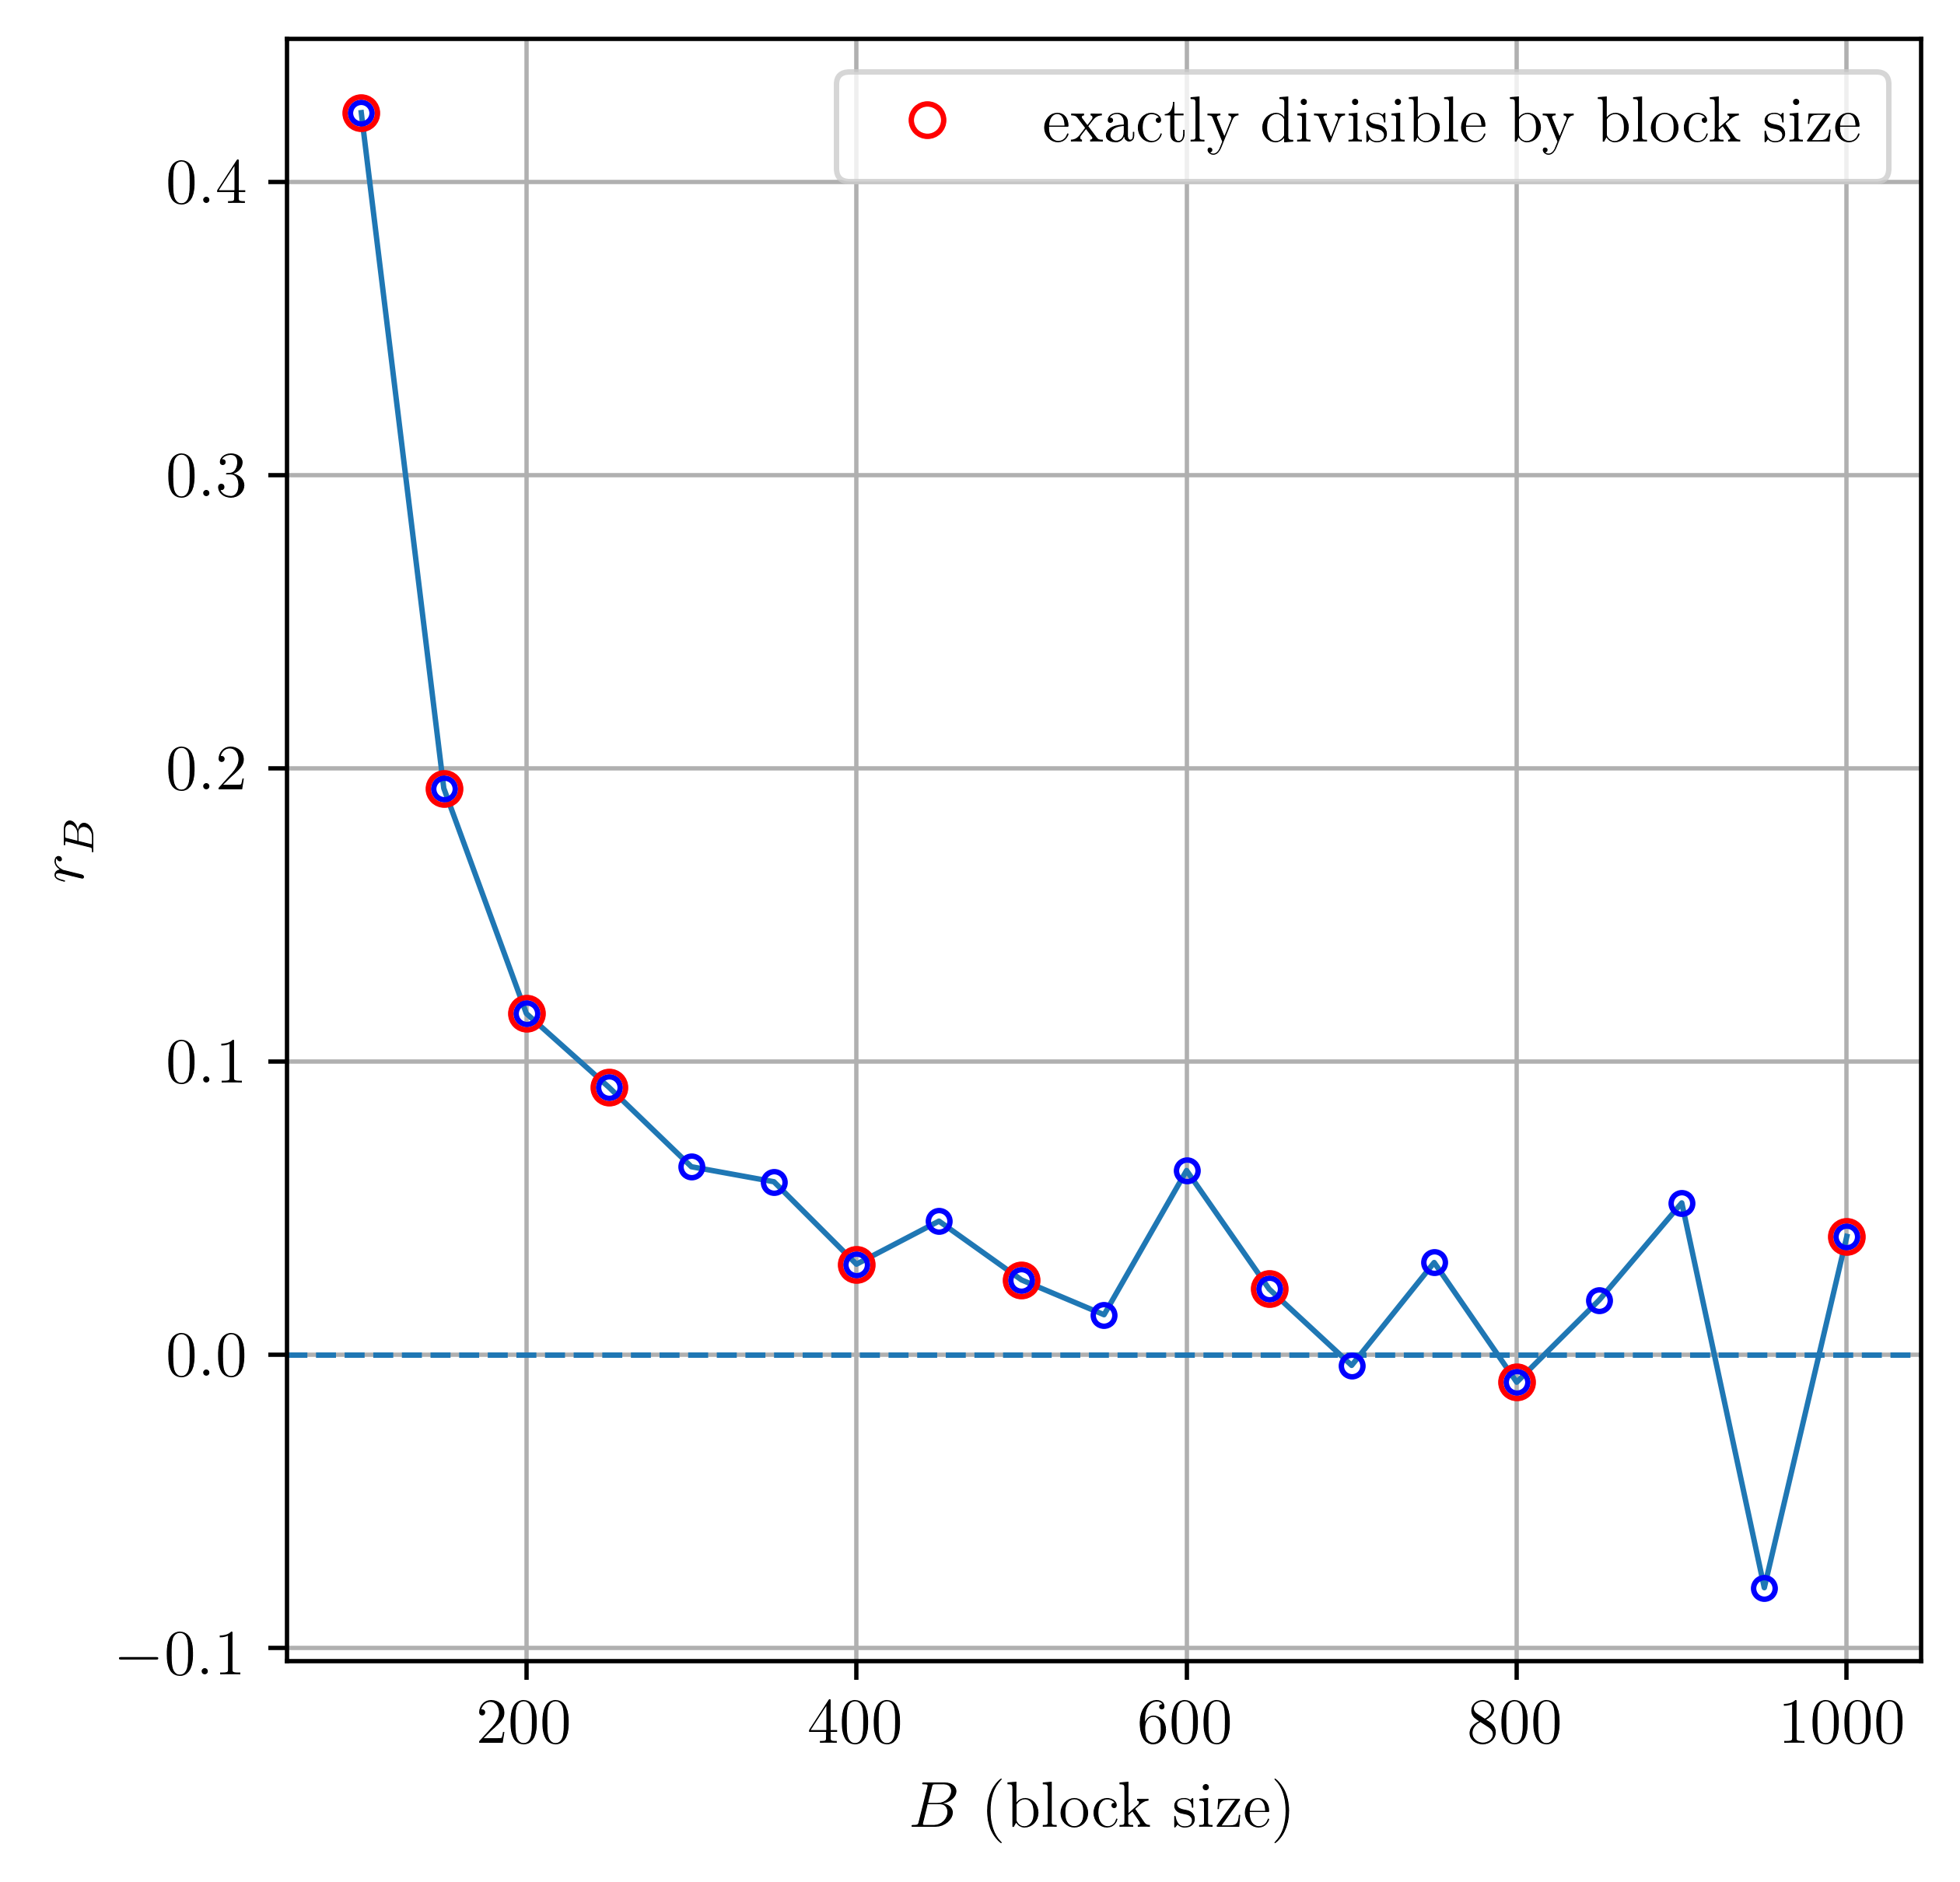

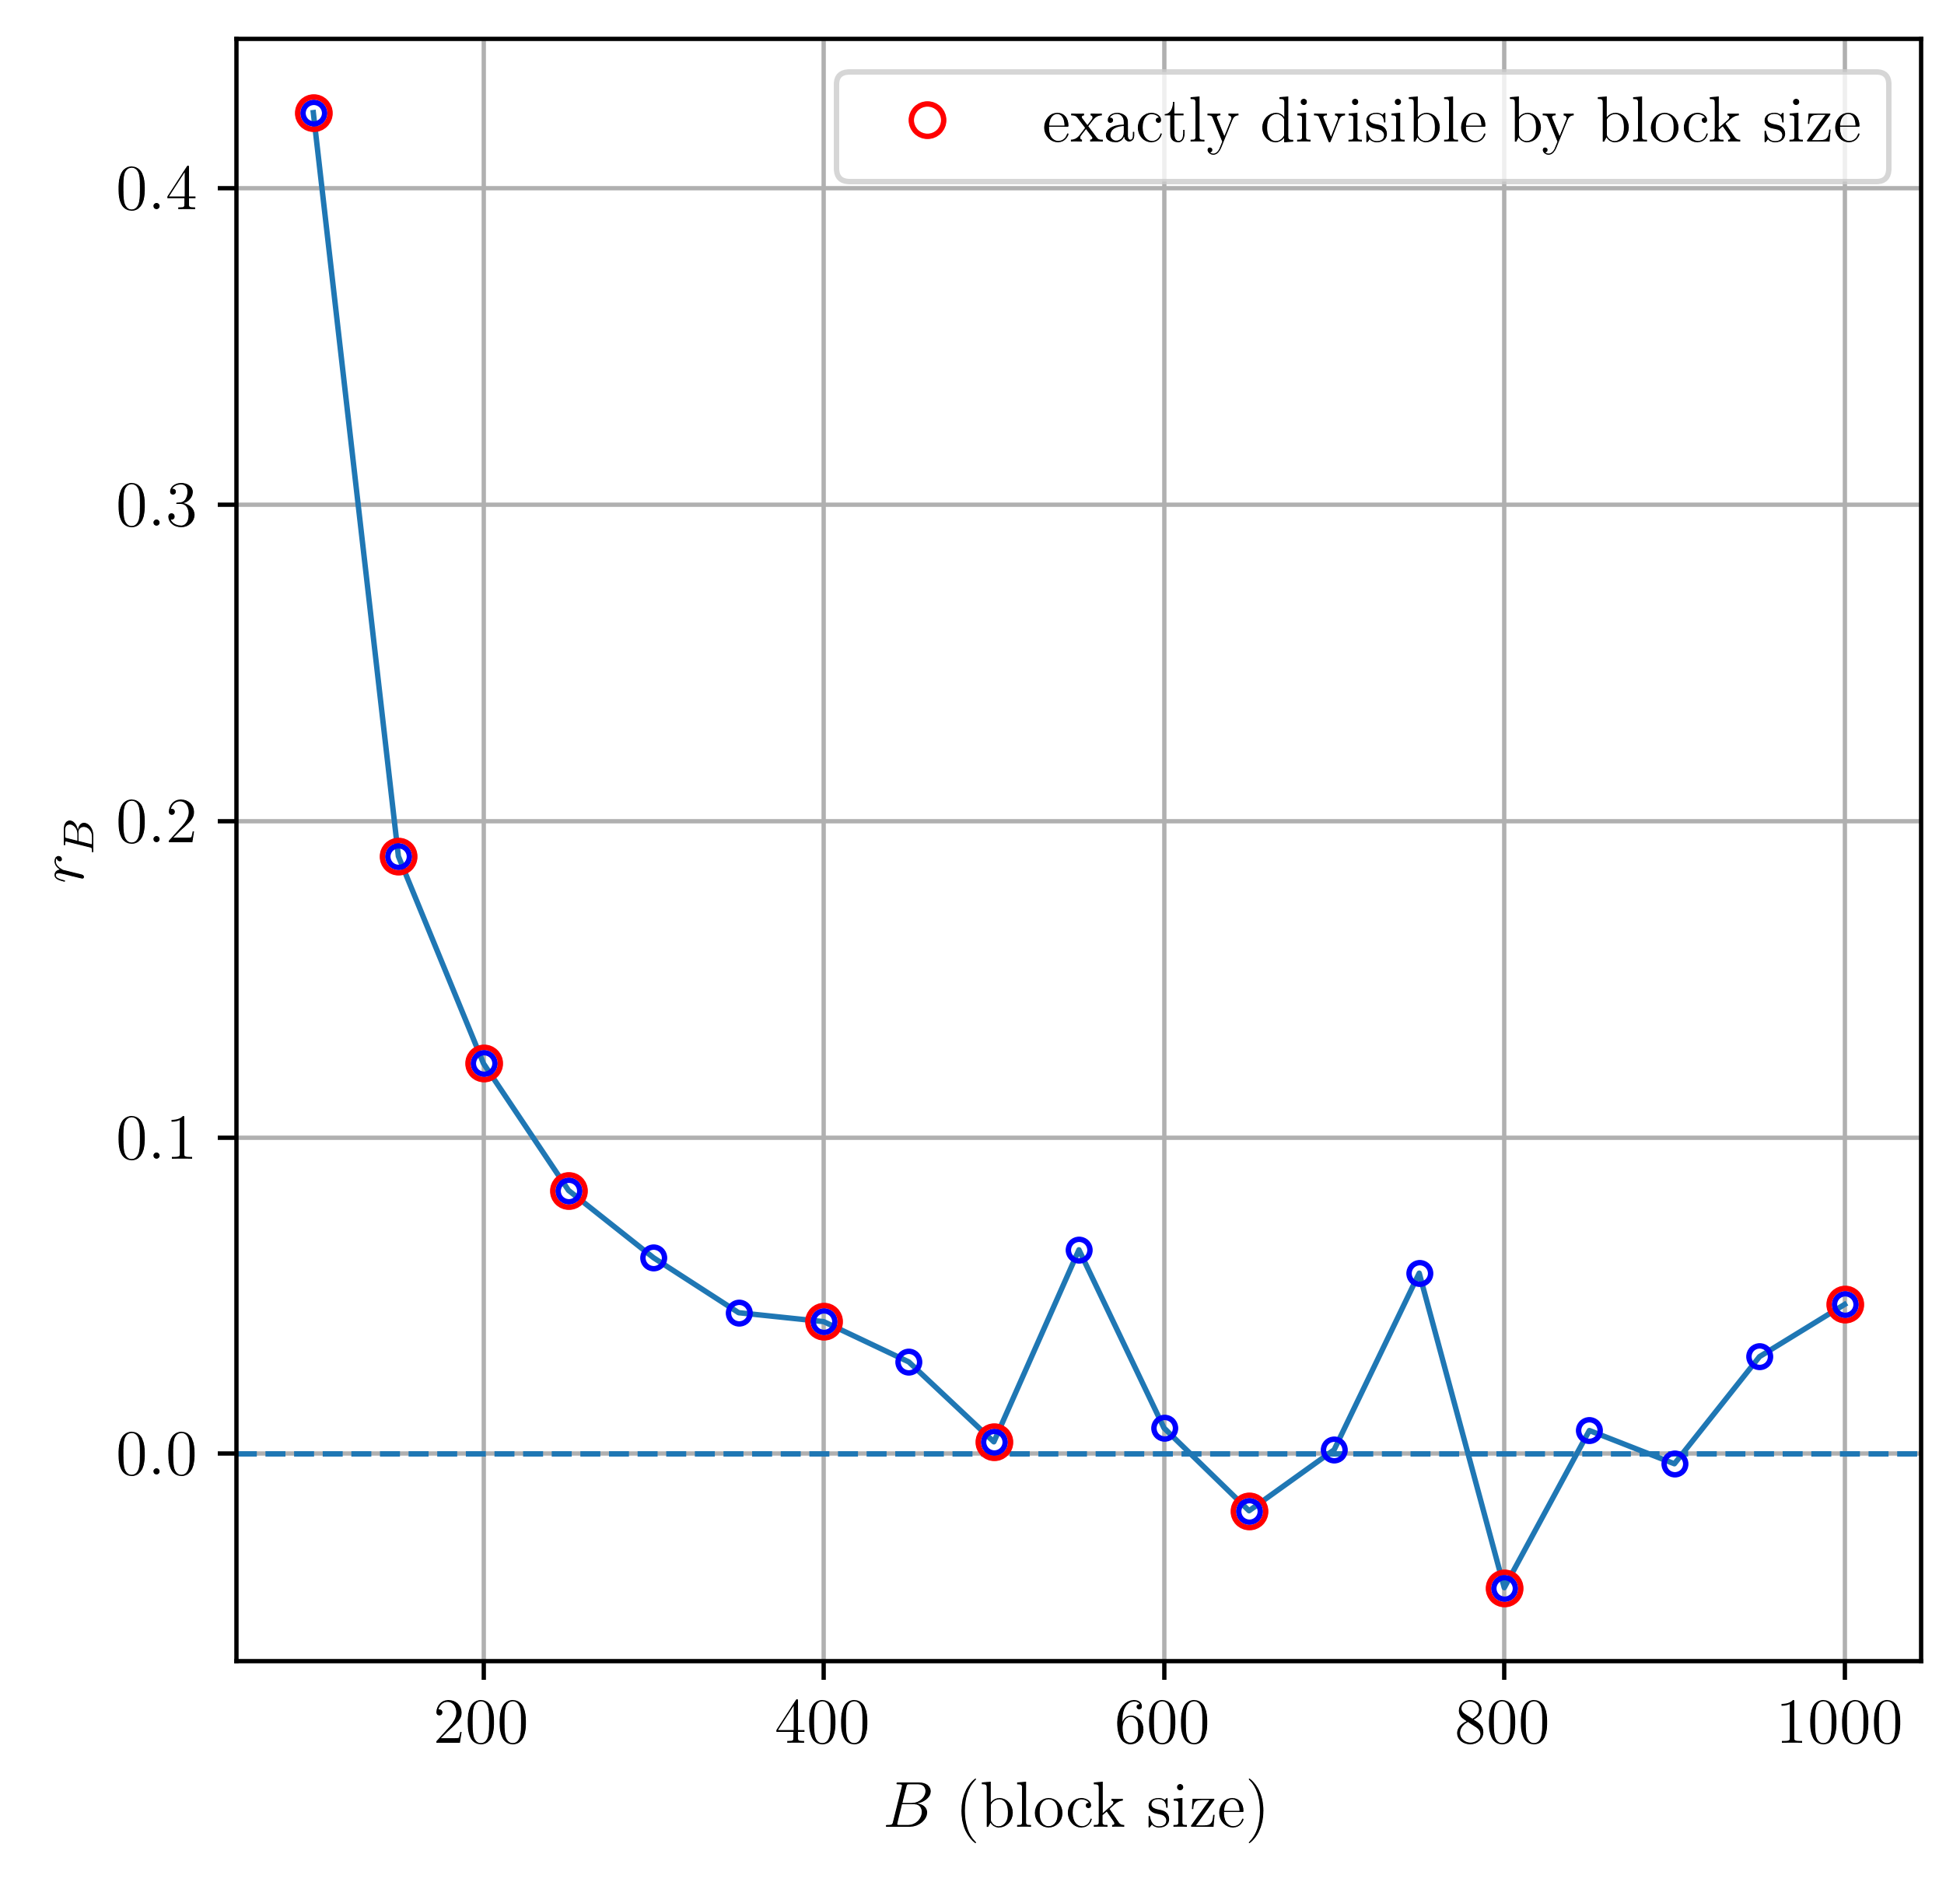

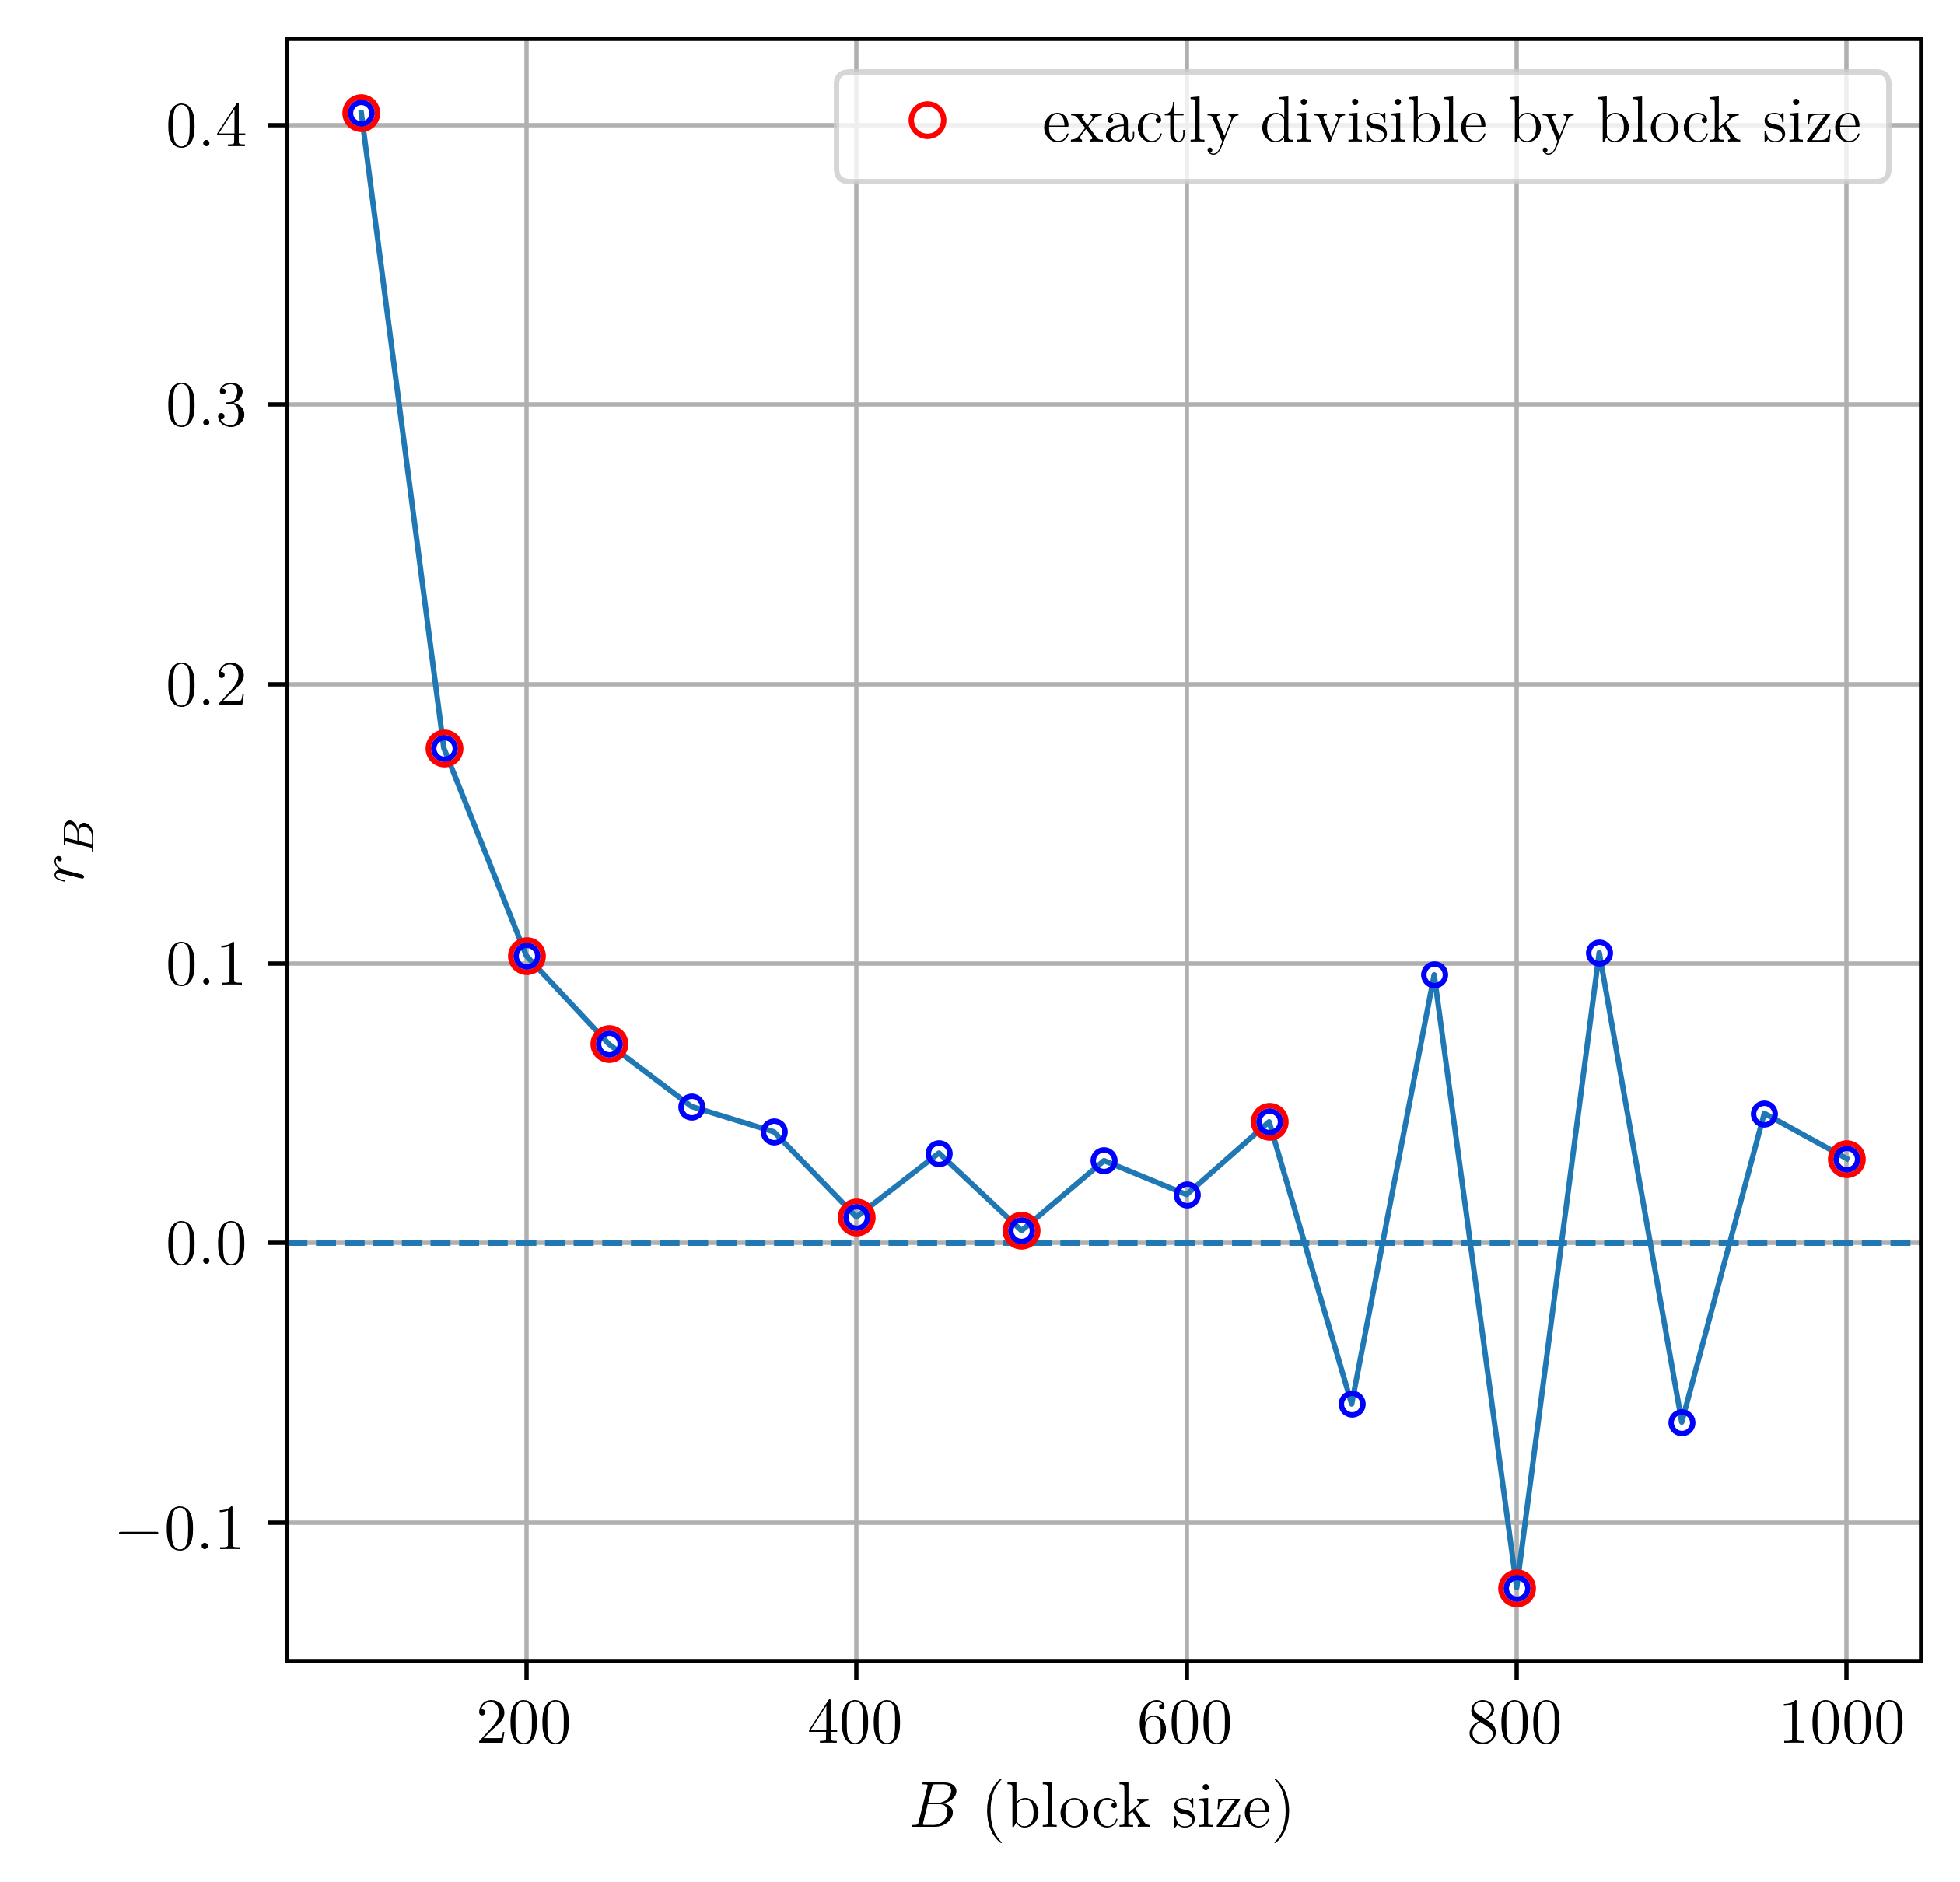

In [47]:
for (i, (ens, X_info_ORG, means, errs)) in enumerate(zip(ensembles, X_info_ORGs, means_vec, errs_vec))
    xs, ys, discarded = Deborah.Rahab.BlockBinScan.nsr_block_scan_blocked_relchange(
        ens,
        X_info_ORG,
        tot_bin,
        means,
        errs,
        win;
        logscale=false,
        save_file=true
    )
    # for (x, y) in zip(xs, ys)
    #     println("bin right-edge = $x, y = $y")
    # end
    # discarded[110]
end

In [48]:
# Deborah.Rahab.BlockBinScan.plot_discarded_vs_blocks(
#     X_info_ORGs[1],
#     tot_bin;
#     style="both"
# )